In [1]:
# =============================================================
# TRABAJO DE FIN DE MÁSTER — MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA
# Universidad Internacional del Ecuador (UIDE)
#
# Título: Comparación de modelos de aprendizaje automático para
#         predecir el tiempo de llegada entre paradas en el
#         sistema BRT Ecovía de Quito utilizando registros
#         históricos de GPS
#
# Autores: Ortega Campus Jhon Henry
#          Ramos Mayorga Oscar Andrés
#          Torres Chango Christian Damian
#
# Notebook 02 — Preprocesamiento
#
# Descripción:
# Este notebook aplica las transformaciones y limpiezas
# identificadas en el EDA sobre el dataset histórico de GPS
# del sistema BRT Ecovía de Quito. El resultado es un dataset
# limpio de 24,308,817 registros listo para el entrenamiento
# de los modelos de aprendizaje automático.
#
# Dataset entrada:  dataset_completo.csv  (28,011,776 registros)
# Dataset salida:   dataset_limpio.csv    (24,308,817 registros)
# Registros conservados: 86.78%
# =============================================================

import pandas as pd
import numpy as np
import warnings
import gc

warnings.filterwarnings('ignore')

print("=" * 60)
print("Notebook 02 — Preprocesamiento")
print("Sistema BRT Ecovía de Quito")
print("=" * 60)
print("Librerías importadas correctamente.")

Notebook 02 — Preprocesamiento
Sistema BRT Ecovía de Quito
Librerías importadas correctamente.


In [2]:
# =============================================================
# Carga del dataset completo
# Se carga el dataset histórico original proporcionado
# por Mivilsoft S.A. para aplicar el preprocesamiento.
#
# Fuente:  Mivilsoft S.A. — sistema SAE
# Período: 15/09/2025 — 15/03/2026
# =============================================================

import gc
gc.collect()

RUTA = 'dataset_completo.csv'
df = pd.read_csv(RUTA)

print(f"Dataset cargado correctamente.")
print(f"Dimensiones:        {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"Speed mínimo:       {df['speed'].min()} knots")
print(f"Speed máximo:       {df['speed'].max():.2f} knots")
print(f"eta mínimo:         {df['eta_next_stop'].min():.3f} min")
print(f"eta máximo:         {df['eta_next_stop'].max():.3f} min")
print(f"is_holiday=True:    {df['is_holiday'].sum():,} registros")

Dataset cargado correctamente.
Dimensiones:        28,011,776 filas × 36 columnas
Speed mínimo:       0.0 knots
Speed máximo:       131.48 knots
eta mínimo:         0.017 min
eta máximo:         138.033 min
is_holiday=True:    0 registros


In [ ]:
# =============================================================
# Preprocesamiento completo
# Se aplican todas las transformaciones identificadas
# en el EDA respetando las características operativas
# de cada ruta del sistema Ecovía.
#
# Pasos:
# 1. Eliminar registros GPS inválidos (valid=False)
# 2. Eliminar buses detenidos (speed=0)
# 3. Convertir speed de knots a km/h
# 4. Eliminar outliers de speed > 60 km/h
# 5. Eliminar outliers de eta por ruta (percentil 99%)
# 6. Corregir is_holiday con feriados reales de Ecuador
# 7. Rellenar nulos de acceleration con 0
# 8. Convertir booleanos a entero (0/1)
# 9. Seleccionar variables del modelo
# =============================================================

import time
t0 = time.time()

rutas_nombres = {
    55.0: 'E1', 58.0: 'E1M', 59.0: 'E2_NS',
    57.0: 'E2_SN', 56.0: 'E3_NS', 62.0: 'E3_SN', 60.0: 'E4'
}

print("=" * 60)
print("PREPROCESAMIENTO — Dataset BRT Ecovía")
print("=" * 60)
print(f"Registros iniciales: {len(df):,}")

# --- PASO 1: Registros GPS inválidos ---
antes = len(df)
df = df[df['valid'] == 't']
print(f"\n[1] Eliminar valid=False:")
print(f"    {antes:,} → {len(df):,} ({antes-len(df):,} eliminados)")

# --- PASO 2: Buses detenidos ---
antes = len(df)
df = df[df['speed'] > 0]
print(f"\n[2] Eliminar speed=0 (buses detenidos):")
print(f"    {antes:,} → {len(df):,} ({antes-len(df):,} eliminados)")

# --- PASO 3: Convertir speed de knots a km/h ---
df['speed'] = df['speed'] * 1.852
print(f"\n[3] Convertir speed de knots a km/h (× 1.852):")
print(f"    Speed mínimo: {df['speed'].min():.2f} km/h")
print(f"    Speed máximo: {df['speed'].max():.2f} km/h")

# --- PASO 4: Outliers de speed ---
# El percentil 99% de todas las rutas está entre
# 51 y 54 km/h. Umbral de 60 km/h para contemplar
# variaciones operativas sin incluir errores GPS.
antes = len(df)
df = df[df['speed'] <= 60]
print(f"\n[4] Eliminar speed > 60 km/h (errores GPS):")
print(f"    {antes:,} → {len(df):,} ({antes-len(df):,} eliminados)")
print(f"    Speed máximo: {df['speed'].max():.2f} km/h")

# --- PASO 5: Outliers de eta por ruta ---
# Umbral basado en percentil 99% de cada ruta.
# Valores cercanos a 0 son válidos (bus casi llegando).
umbrales_eta = {
    55.0: 7.0,   # E1    → p99=6.5 min
    58.0: 6.5,   # E1M   → p99=6.0 min
    59.0: 7.5,   # E2_NS → p99=7.1 min
    57.0: 5.0,   # E2_SN → p99=4.4 min
    56.0: 6.0,   # E3_NS → p99=5.7 min
    62.0: 6.5,   # E3_SN → p99=6.0 min
    60.0: 7.0,   # E4    → p99=6.8 min
}

masks = []
for route_id, umbral in umbrales_eta.items():
    masks.append(
        (df['route_id'] == route_id) &
        (df['eta_next_stop'] <= umbral)
    )

df = df[pd.concat(masks, axis=1).any(axis=1)]
print(f"\n[5] Eliminar outliers eta por ruta:")
print(f"    Registros conservados: {len(df):,}")
print(f"\n    {'Ruta':<8} {'Umbral':>8} {'Registros':>12} {'eta máx':>10}")
print(f"    {'-'*42}")
for route_id, umbral in umbrales_eta.items():
    total   = (df['route_id'] == route_id).sum()
    max_eta = df[df['route_id']==route_id]['eta_next_stop'].max()
    print(f"    {rutas_nombres[route_id]:<8} {umbral:>8.1f} "
          f"{total:>12,} {max_eta:>10.3f}")

# --- PASO 6: Corregir is_holiday ---
# Feriados nacionales de Ecuador en el período del dataset.
FERIADOS_ECUADOR = [
    "2025-10-09",  # Independencia de Guayaquil
    "2025-11-02",  # Día de Difuntos
    "2025-11-03",  # Independencia de Cuenca
    "2025-12-25",  # Navidad
    "2025-12-31",  # Fin de año
    "2026-01-01",  # Año Nuevo
    "2026-02-16",  # Carnaval
    "2026-02-17",  # Carnaval
    "2026-03-06",  # Viernes Santo
    # Feriados locales del Distrito Metropolitano de Quito
    "2025-12-06",  # Fundación de Quito
]
feriados_set = set(pd.to_datetime(FERIADOS_ECUADOR).date)
df['date'] = pd.to_datetime(df['date']).dt.date
df['is_holiday'] = df['date'].apply(lambda d: d in feriados_set)
print(f"\n[6] Corregir is_holiday:")
print(f"    Antes:  0 registros (error en dataset original)")
print(f"    Después: {df['is_holiday'].sum():,} registros "
      f"({df['is_holiday'].sum()/len(df)*100:.2f}%)")

# --- PASO 7: Nulos de acceleration ---
antes_nulos = df['acceleration'].isnull().sum()
df['acceleration'] = df['acceleration'].fillna(0)
print(f"\n[7] Nulos de acceleration rellenados con 0: {antes_nulos}")

# --- PASO 8: Booleanos a entero ---
for col in ['is_weekend', 'is_peak_hour', 'is_holiday']:
    df[col] = df[col].astype(int)
print(f"\n[8] Booleanos convertidos a entero (0/1):")
print(f"    is_weekend, is_peak_hour, is_holiday")

# --- PASO 9: Seleccionar variables ---
FEATURES = [
    'route_id', 'current_stop_id', 'current_stop_order',
    'distance_to_next_stop', 'speed', 'acceleration',
    'time_since_last_stop', 'hour', 'day_of_week',
    'is_weekend', 'is_peak_hour', 'is_holiday',
    'eta_next_stop',
    'trip_id',    # auxiliar para construcción de ventanas
    'timestamp',  # auxiliar para split temporal
]
df = df[FEATURES]
print(f"\n[9] Variables seleccionadas:")
print(f"    Variables predictoras:  12")
print(f"    Variable objetivo:       1  (eta_next_stop)")
print(f"    Variables auxiliares:    2  (trip_id, timestamp)")
print(f"    Total columnas:         {len(FEATURES)}")

# --- RESUMEN FINAL ---
print(f"\n{'=' * 60}")
print(f"RESUMEN DEL PREPROCESAMIENTO")
print(f"{'=' * 60}")
print(f"  Registros originales:  28,011,776")
print(f"  Registros finales:     {len(df):,}")
print(f"  Registros eliminados:  {28011776 - len(df):,}")
print(f"  Porcentaje conservado: {len(df)/28011776*100:.2f}%")
print(f"  Tiempo total:          {(time.time()-t0)/60:.1f} minutos")

PREPROCESAMIENTO — Dataset BRT Ecovía
Registros iniciales: 28,011,776

[1] Eliminar valid=False:
    28,011,776 → 28,011,776 (0 eliminados)

[2] Eliminar speed=0 (buses detenidos):
    28,011,776 → 24,912,217 (3,099,559 eliminados)

[3] Convertir speed de knots a km/h (× 1.852):
    Speed mínimo: 4.00 km/h
    Speed máximo: 243.50 km/h

[4] Eliminar speed > 60 km/h (errores GPS):
    24,912,217 → 24,887,640 (24,577 eliminados)
    Speed máximo: 59.80 km/h

[5] Eliminar outliers eta por ruta:
    Registros conservados: 24,308,817

    Ruta       Umbral    Registros    eta máx
    ------------------------------------------
    E1            7.0    8,568,477      7.000
    E1M           6.5    4,302,693      6.500
    E2_NS         7.5    4,055,368      7.500
    E2_SN         5.0    2,803,901      5.000
    E3_NS         6.0    2,167,708      6.000
    E3_SN         6.5    1,488,253      6.500
    E4            7.0      922,417      7.000

[6] Corregir is_holiday:
    Antes:  0 registros

Procesando rutas...
 Ruta E1: 30,017 segmentos
 Ruta E1M: 22,932 segmentos
 Ruta E2_NS: 23,868 segmentos
 Ruta E2_SN: 12,875 segmentos
 Ruta E3_NS: 11,374 segmentos
 Ruta E3_SN: 23,952 segmentos
 Ruta E4: 16,052 segmentos


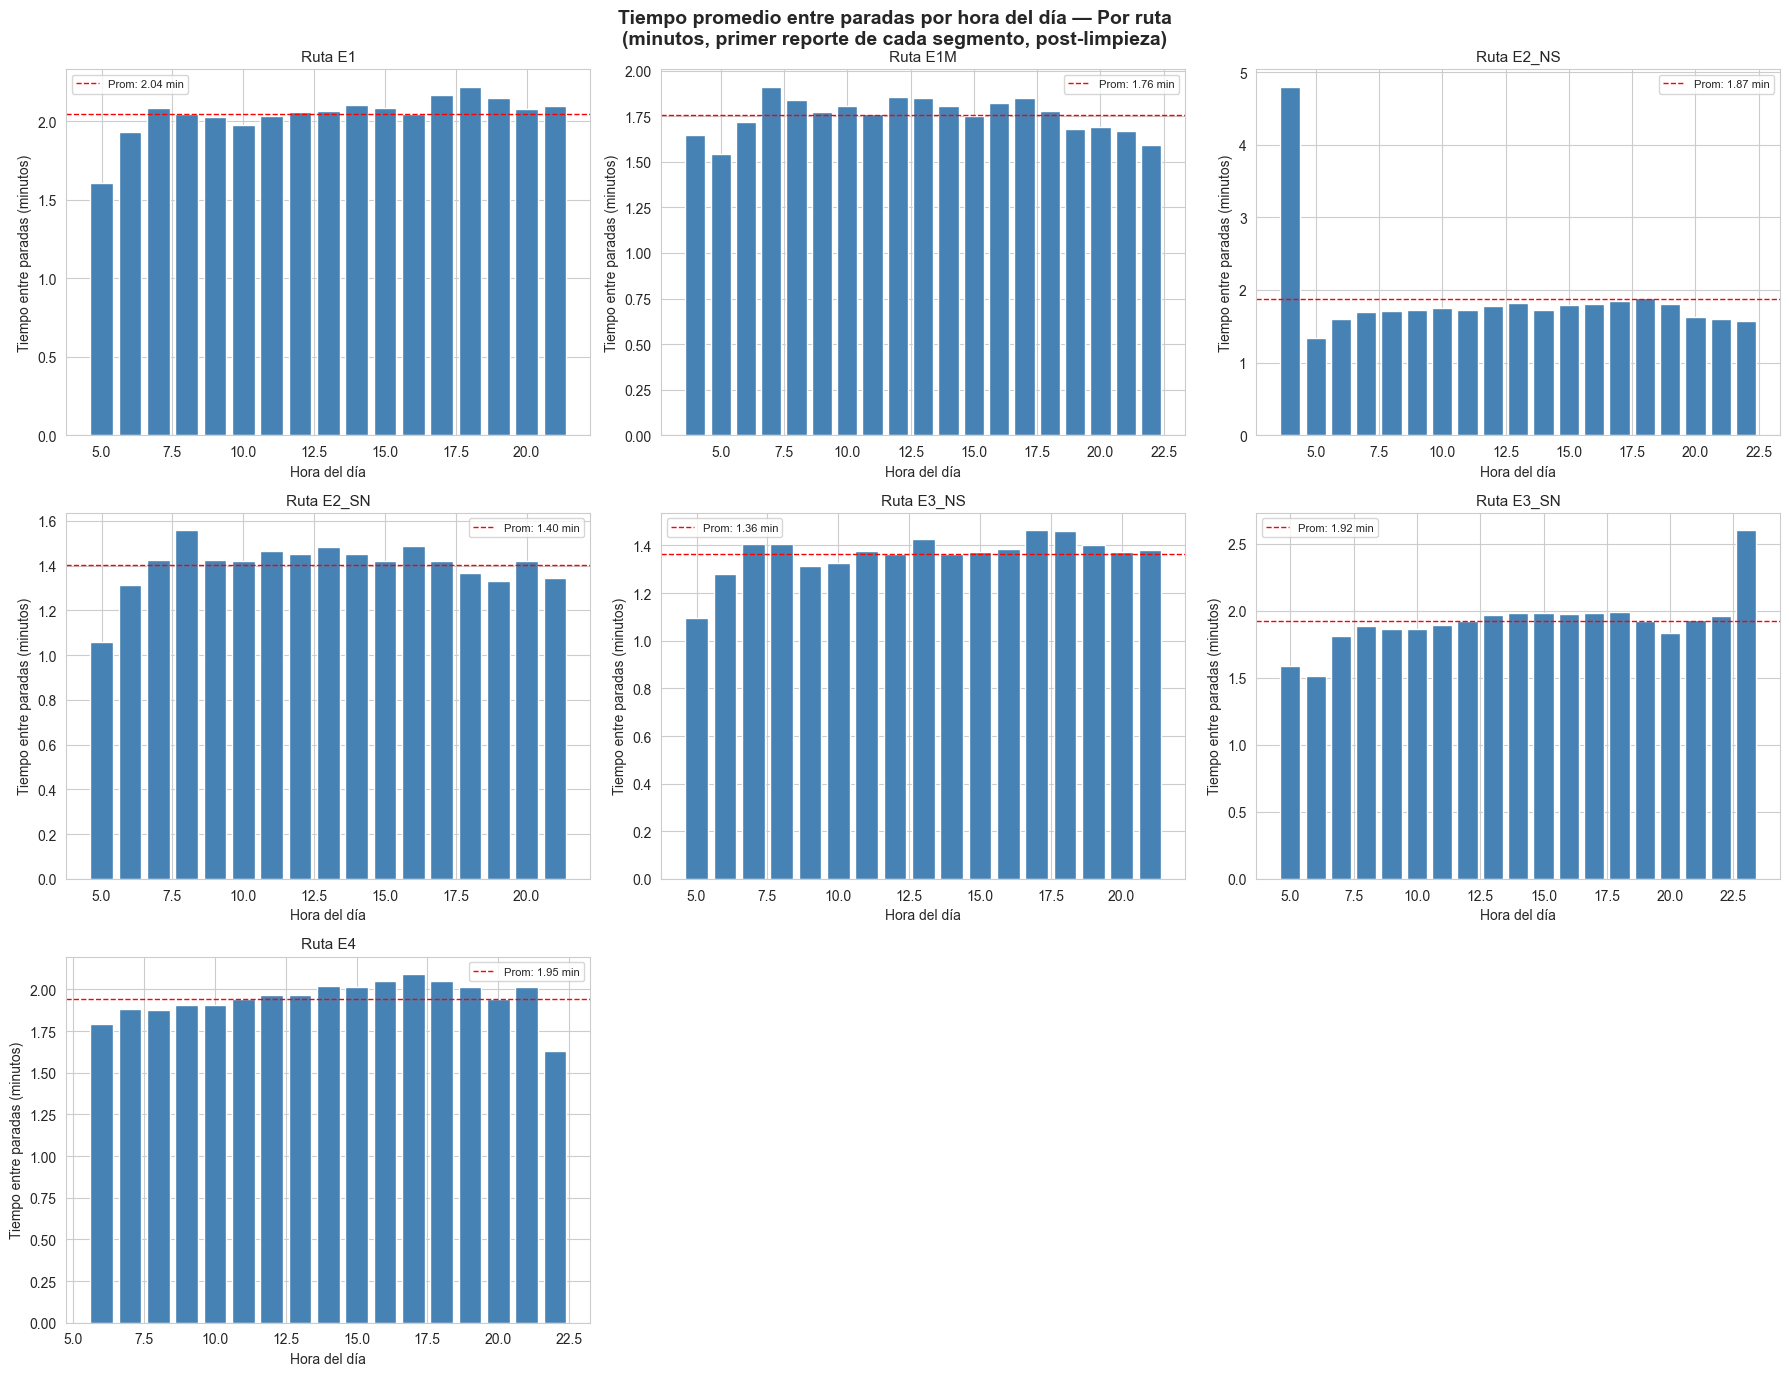

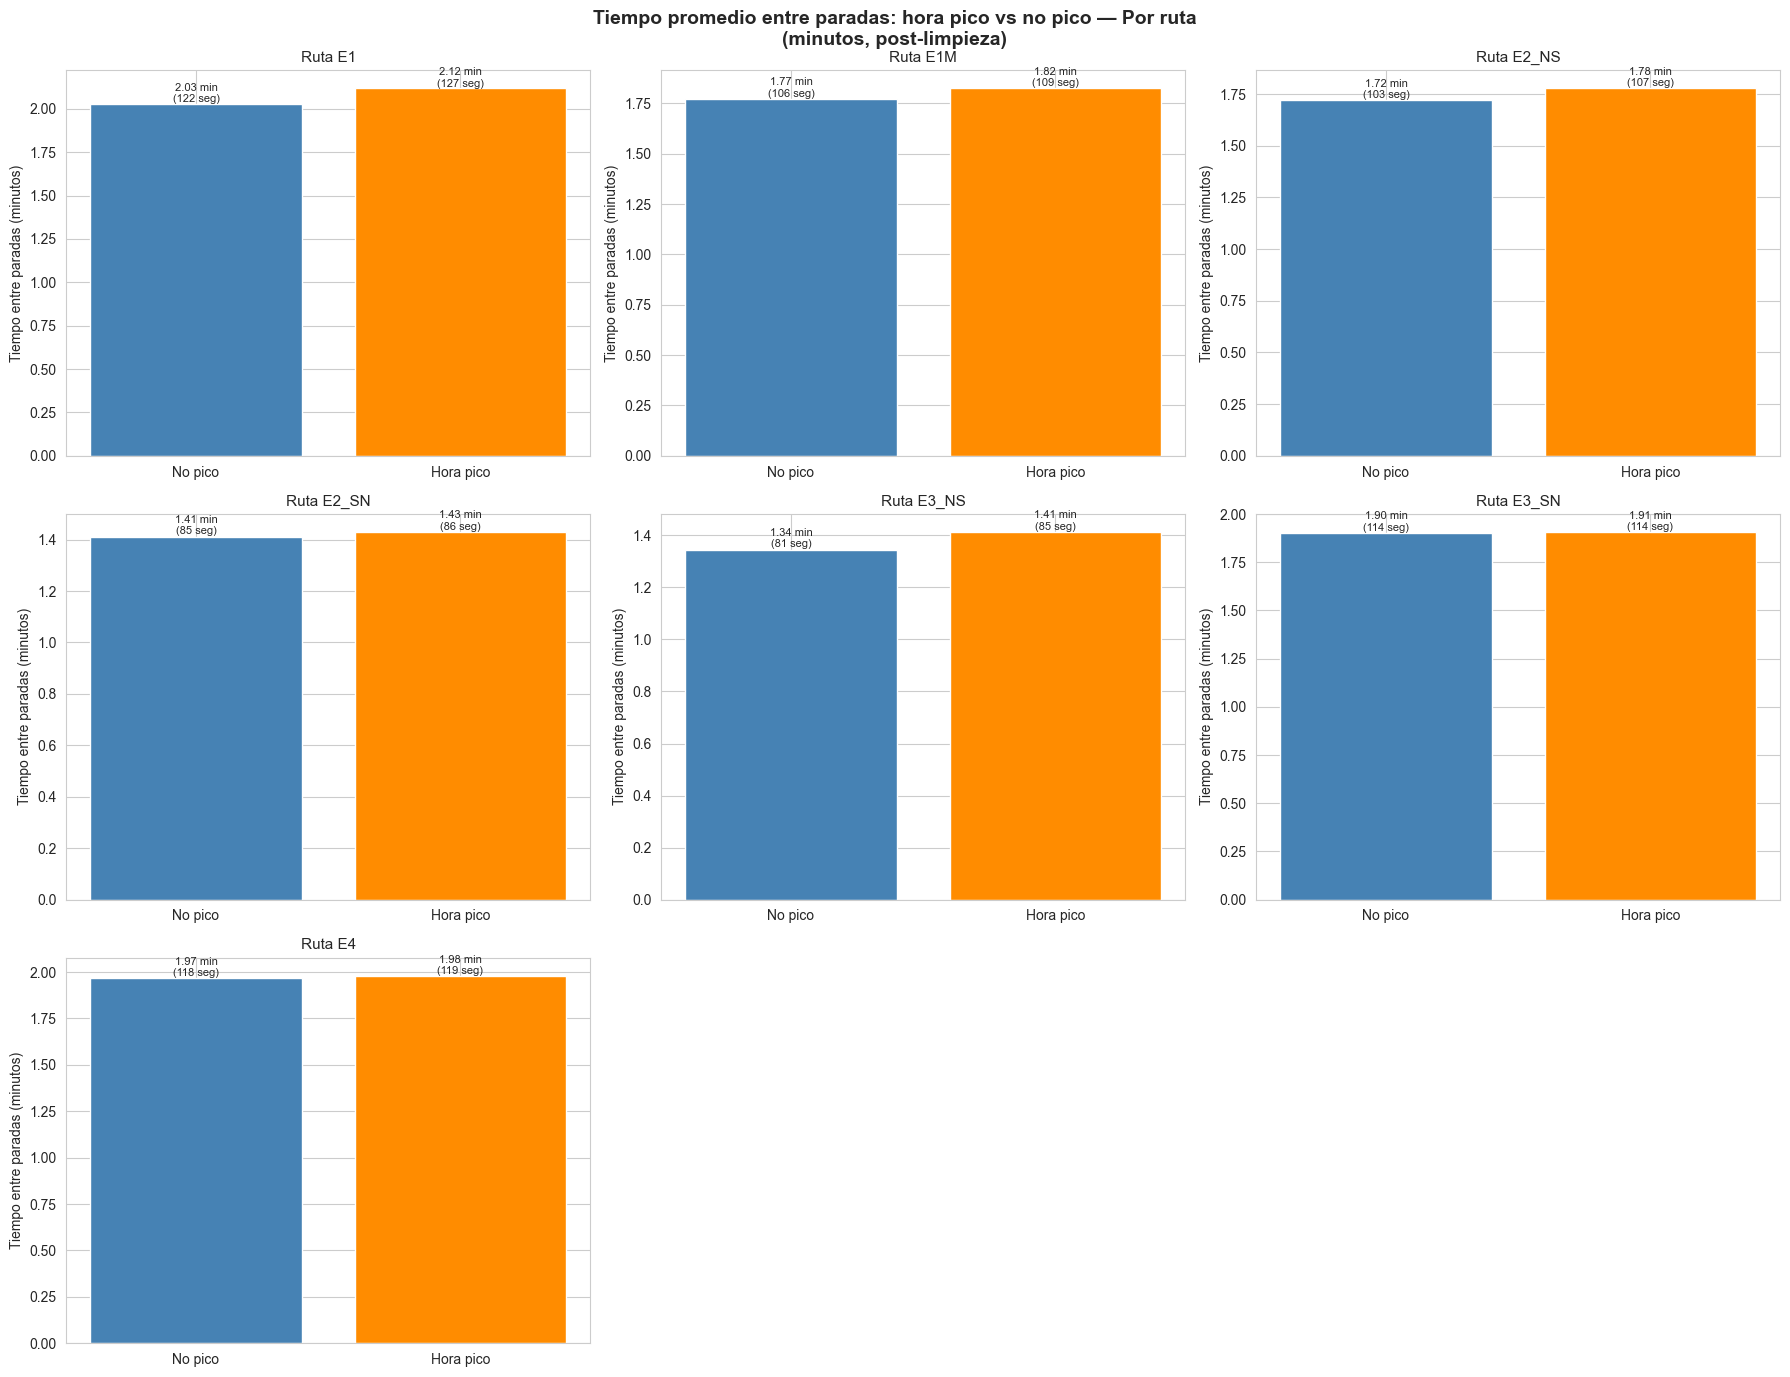

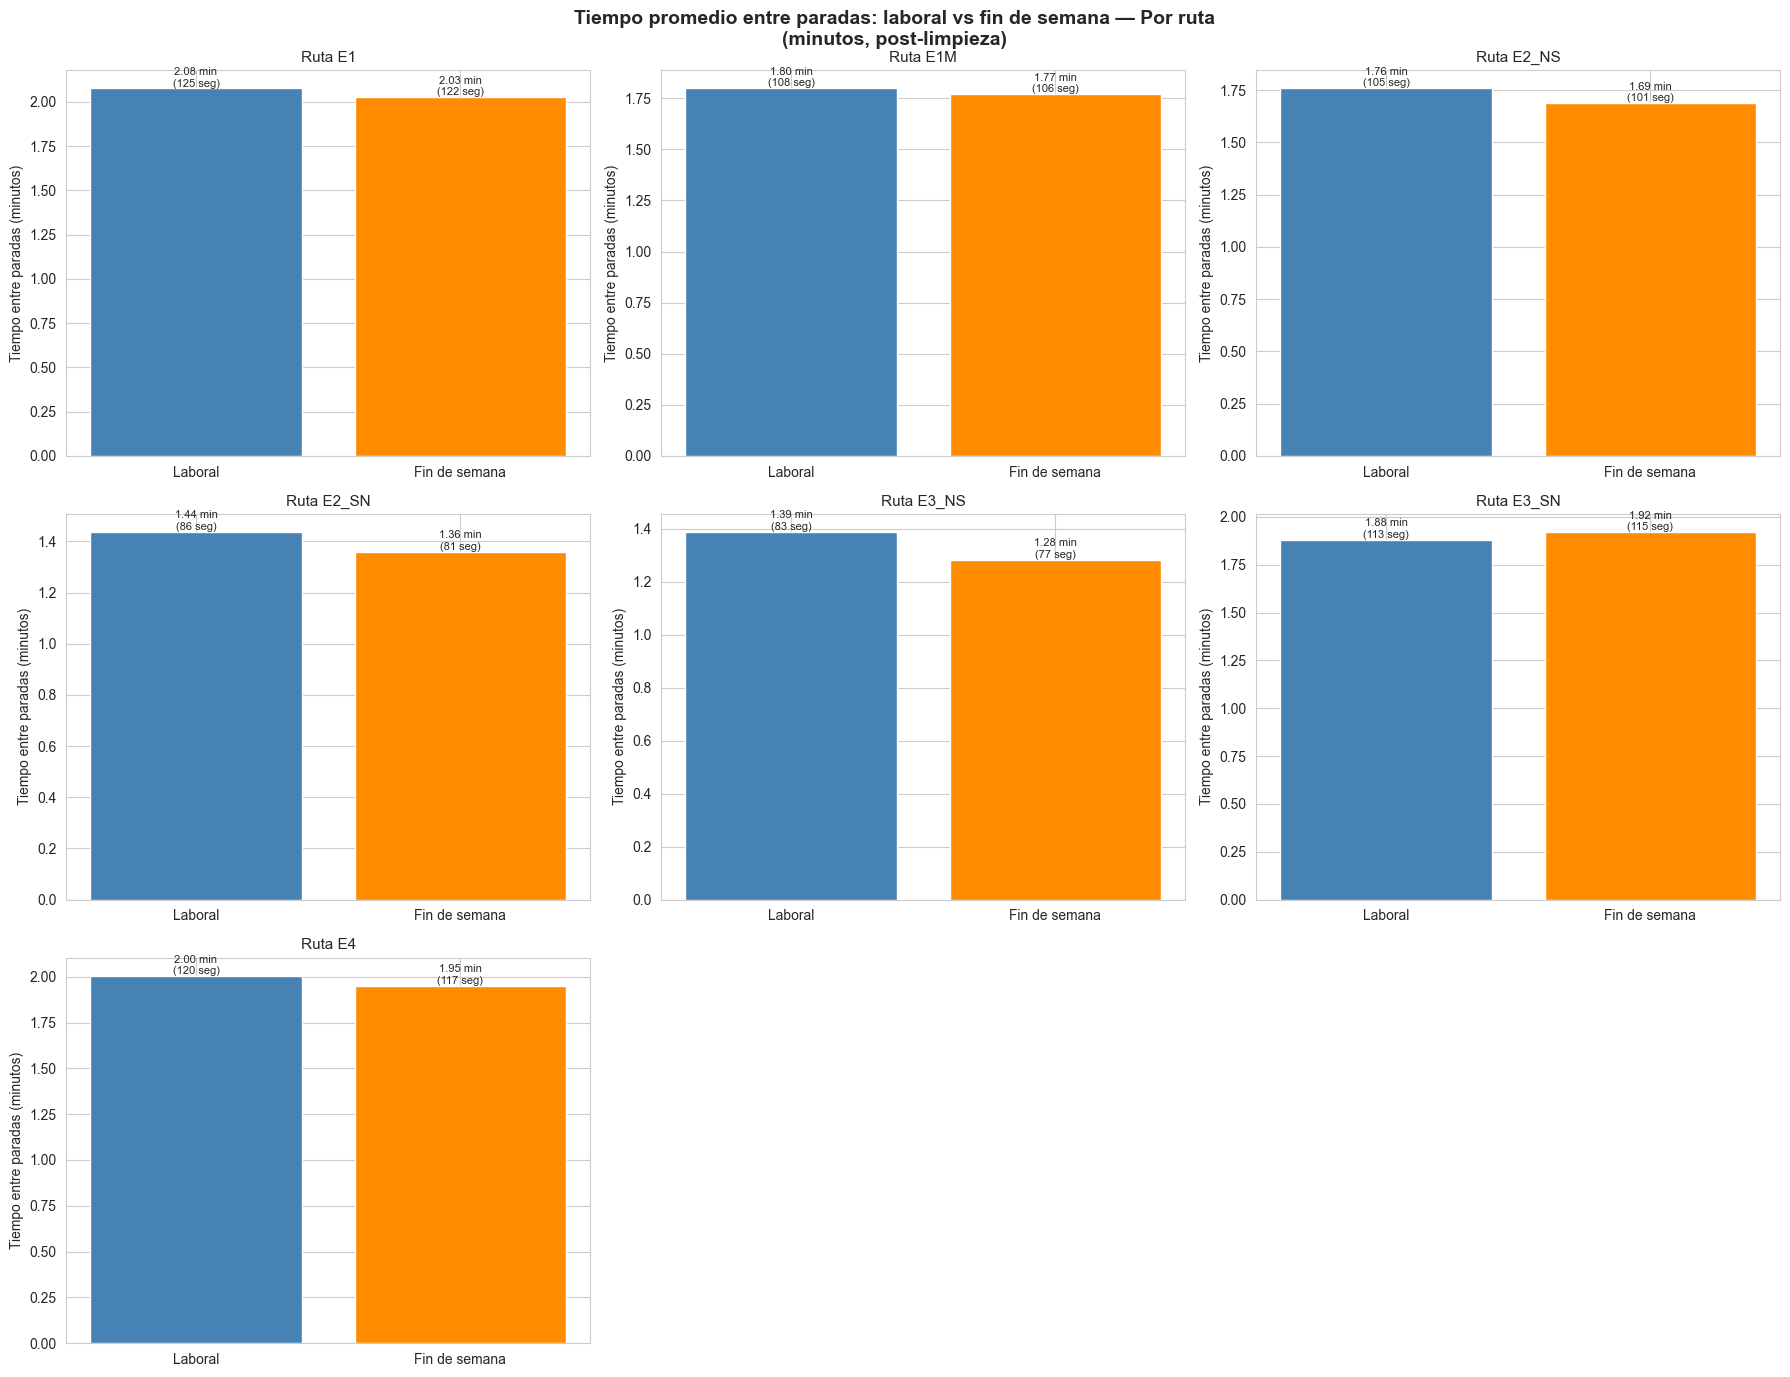


RESUMEN EDA POST-LIMPIEZA

--- Tiempo promedio entre paradas por ruta ---
(promedio de todos los segmentos en todos los horarios)

Ruta      Tiempo prom (min)  Tiempo prom (seg)
----------------------------------------------
E1                    2.045              122.7
E1M                   1.755              105.3
E2_NS                 1.874              112.5
E2_SN                 1.403               84.2
E3_NS                 1.364               81.8
E3_SN                 1.919              115.2
E4                    1.945              116.7

--- Impacto de la hora pico en el tiempo entre paradas ---
(comparando segmentos en hora pico vs fuera de hora pico)

Ruta        No pico   Hora pico   Diferencia Impacto
------------------------------------------------------------
E1          2.029min     2.118min      5.3 seg  ↑ más lento
E1M         1.774min     1.824min      3.0 seg  ↑ más lento
E2_NS       1.721min     1.777min      3.4 seg  ↑ más lento
E2_SN       1.411min     1.429mi

In [7]:
# =============================================================
# EDA post-limpieza
# Se verifica que el preprocesamiento no distorsionó
# los patrones identificados en el EDA inicial.
# Se procesan 700 viajes por ruta de forma secuencial
# para optimizar el uso de memoria RAM.
# =============================================================

import matplotlib.pyplot as plt
import seaborn as sns
import gc

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

rutas_nombres = {
    55.0: 'E1', 58.0: 'E1M', 59.0: 'E2_NS',
    57.0: 'E2_SN', 56.0: 'E3_NS', 62.0: 'E3_SN', 60.0: 'E4'
}

# Procesar ruta por ruta para optimizar RAM
print("Procesando rutas...")
resultados_post = {}

for route_id, nombre_ruta in rutas_nombres.items():
    df_ruta = df[df['route_id'] == route_id]
    viajes_ruta = df_ruta['trip_id'].drop_duplicates()
    n = min(700, len(viajes_ruta))
    viajes_muestra = viajes_ruta.sample(n=n, random_state=42)
    df_muestra = df_ruta[df_ruta['trip_id'].isin(viajes_muestra)].copy()
    df_muestra['timestamp'] = pd.to_datetime(df_muestra['timestamp'])

    df_seg = (df_muestra.sort_values('timestamp')
                        .groupby(['trip_id', 'current_stop_id'])
                        .first()
                        .reset_index())

    resultados_post[nombre_ruta] = {
        'eta_hora': df_seg.groupby('hour')['eta_next_stop'].mean(),
        'eta_pico': df_seg.groupby('is_peak_hour')['eta_next_stop'].mean(),
        'eta_fds':  df_seg.groupby('is_weekend')['eta_next_stop'].mean(),
        'corr_op':  df_seg[['speed', 'distance_to_next_stop',
                             'time_since_last_stop', 'acceleration',
                             'eta_next_stop']].corr()['eta_next_stop'].drop('eta_next_stop'),
        'segmentos': len(df_seg)
    }

    print(f" Ruta {nombre_ruta}: {len(df_seg):,} segmentos")
    del df_ruta, df_muestra, df_seg
    gc.collect()

# =============================================================
# Gráfica 1 — Tiempo promedio entre paradas por hora
# =============================================================
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('Tiempo promedio entre paradas por hora del día — Por ruta\n'
             '(minutos, primer reporte de cada segmento, post-limpieza)',
             fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, (nombre_ruta, datos) in enumerate(resultados_post.items()):
    eta_hora = datos['eta_hora']
    axes[i].bar(eta_hora.index, eta_hora.values, color='steelblue')
    axes[i].set_title(f'Ruta {nombre_ruta}', fontsize=11)
    axes[i].set_xlabel('Hora del día')
    axes[i].set_ylabel('Tiempo entre paradas (minutos)')
    axes[i].axhline(eta_hora.mean(), color='red', linestyle='--',
                    linewidth=1,
                    label=f'Prom: {eta_hora.mean():.2f} min')
    axes[i].legend(fontsize=8)

axes[-1].set_visible(False)
axes[-2].set_visible(False)
plt.tight_layout()
plt.savefig('post_eta_hora_ruta.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================
# Gráfica 2 — Hora pico vs no pico
# =============================================================
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('Tiempo promedio entre paradas: hora pico vs no pico — Por ruta\n'
             '(minutos, post-limpieza)',
             fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, (nombre_ruta, datos) in enumerate(resultados_post.items()):
    eta_pico = datos['eta_pico']
    bars = axes[i].bar(['No pico', 'Hora pico'], eta_pico.values,
                       color=['steelblue', 'darkorange'])
    axes[i].set_title(f'Ruta {nombre_ruta}', fontsize=11)
    axes[i].set_ylabel('Tiempo entre paradas (minutos)')
    for j, v in enumerate(eta_pico.values):
        axes[i].text(j, v + 0.01, f'{v:.2f} min\n({v*60:.0f} seg)',
                     ha='center', fontsize=8)

axes[-1].set_visible(False)
axes[-2].set_visible(False)
plt.tight_layout()
plt.savefig('post_eta_pico_ruta.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================
# Gráfica 3 — Laboral vs fin de semana
# =============================================================
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('Tiempo promedio entre paradas: laboral vs fin de semana — Por ruta\n'
             '(minutos, post-limpieza)',
             fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, (nombre_ruta, datos) in enumerate(resultados_post.items()):
    eta_fds = datos['eta_fds']
    axes[i].bar(['Laboral', 'Fin de semana'], eta_fds.values,
                color=['steelblue', 'darkorange'])
    axes[i].set_title(f'Ruta {nombre_ruta}', fontsize=11)
    axes[i].set_ylabel('Tiempo entre paradas (minutos)')
    for j, v in enumerate(eta_fds.values):
        axes[i].text(j, v + 0.01, f'{v:.2f} min\n({v*60:.0f} seg)',
                     ha='center', fontsize=8)

axes[-1].set_visible(False)
axes[-2].set_visible(False)
plt.tight_layout()
plt.savefig('post_eta_fds_ruta.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================
# Resumen numérico con interpretación clara
# =============================================================
print("\n" + "=" * 65)
print("RESUMEN EDA POST-LIMPIEZA")
print("=" * 65)

print("\n--- Tiempo promedio entre paradas por ruta ---")
print("(promedio de todos los segmentos en todos los horarios)")
print(f"\n{'Ruta':<8} {'Tiempo prom (min)':>18} {'Tiempo prom (seg)':>18}")
print("-" * 46)
for nombre_ruta, datos in resultados_post.items():
    eta_prom = datos['eta_hora'].mean()
    print(f"{nombre_ruta:<8} {eta_prom:>18.3f} {eta_prom*60:>18.1f}")

print("\n--- Impacto de la hora pico en el tiempo entre paradas ---")
print("(comparando segmentos en hora pico vs fuera de hora pico)")
print(f"\n{'Ruta':<8} {'No pico':>10} {'Hora pico':>11} "
      f"{'Diferencia':>12} {'Impacto'}")
print("-" * 60)
for nombre_ruta, datos in resultados_post.items():
    eta_pico = datos['eta_pico']
    no_pico  = eta_pico.iloc[0]
    pico     = eta_pico.iloc[1]
    dif_seg  = (pico - no_pico) * 60
    simbolo  = '↑ más lento' if dif_seg > 0 else '↓ más rápido'
    print(f"{nombre_ruta:<8} {no_pico:>8.3f}min {pico:>9.3f}min "
          f"{abs(dif_seg):>8.1f} seg  {simbolo}")

print("\n--- Impacto del fin de semana en el tiempo entre paradas ---")
print("(comparando segmentos en días laborales vs fin de semana)")
print(f"\n{'Ruta':<8} {'Laboral':>10} {'Fin semana':>12} "
      f"{'Diferencia':>12} {'Impacto'}")
print("-" * 62)
for nombre_ruta, datos in resultados_post.items():
    eta_fds = datos['eta_fds']
    laboral = eta_fds.iloc[0]
    fds     = eta_fds.iloc[1]
    dif_seg = (fds - laboral) * 60
    simbolo = '↑ más lento' if dif_seg > 0 else '↓ más rápido'
    print(f"{nombre_ruta:<8} {laboral:>8.3f}min {fds:>10.3f}min "
          f"{abs(dif_seg):>8.1f} seg  {simbolo}")

print("\n--- Variable más predictiva del tiempo entre paradas ---")
print("(correlación con eta_next_stop, valores entre -1 y 1)")
print("(más cercano a 1 o -1 = más predictiva)")
print(f"\n{'Ruta':<8} {'Variable más importante':>25} "
      f"{'Correlación':>12} {'Interpretación'}")
print("-" * 75)
for nombre_ruta, datos in resultados_post.items():
    mejor_var = datos['corr_op'].abs().idxmax()
    mejor_val = datos['corr_op'][mejor_var]
    if abs(mejor_val) >= 0.5:
        nivel = 'Alta'
    elif abs(mejor_val) >= 0.2:
        nivel = 'Moderada'
    else:
        nivel = 'Baja'
    print(f"{nombre_ruta:<8} {mejor_var:>25} {mejor_val:>12.4f}  {nivel}")

gc.collect()
print("\n EDA post-limpieza completado")

El preprocesamiento redujo el dataset de 28 millones a 24.3 millones de registros, conservando el 86.78% de los datos. La desviación estándar de eta_next_stop se redujo de 4.48 a 1.23 minutos, lo que indica que los outliers fueron eliminados correctamente. La velocidad máxima quedó en 59.80 km/h, consistente con la operación real del sistema Ecovía en zona urbana. Los feriados fueron corregidos, pasando de 0 a 925,403 registros correctamente marcados

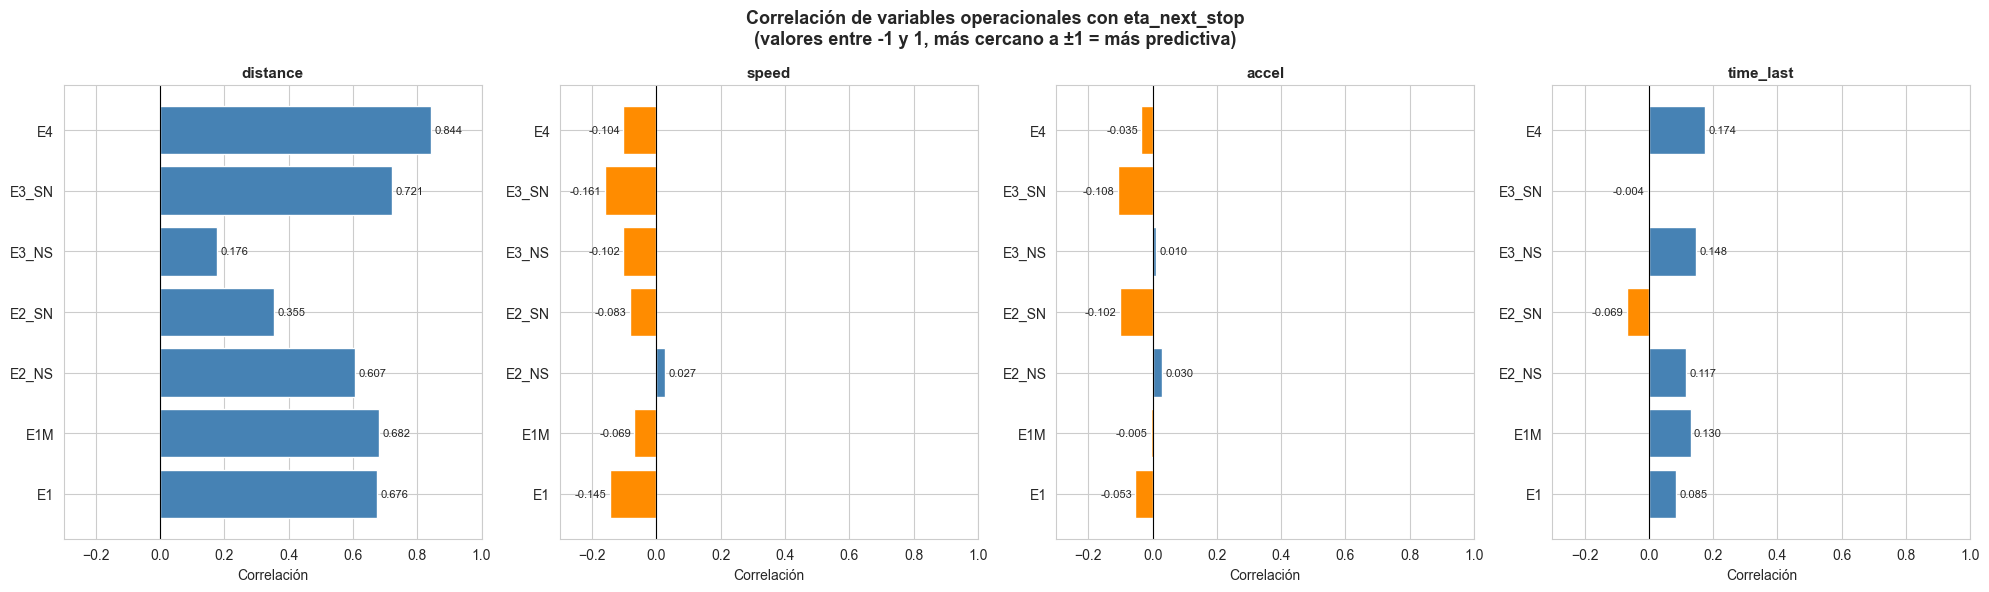


CORRELACIÓN COMPLETA — VARIABLES OPERACIONALES vs eta_next_stop
(azul = positiva: más variable = más eta)
(naranja = negativa: más variable = menos eta)

Ruta       distance      speed      accel  time_last
--------------------------------------------------
E1           0.6757    -0.1451    -0.0535     0.0847
E1M          0.6816    -0.0694    -0.0048     0.1302
E2_NS        0.6066     0.0271     0.0305     0.1168
E2_SN        0.3551    -0.0832    -0.1020    -0.0689
E3_NS        0.1762    -0.1025     0.0104     0.1480
E3_SN        0.7210    -0.1614    -0.1078    -0.0036
E4           0.8439    -0.1036    -0.0355     0.1742


In [8]:
# =============================================================
# Correlación completa de variables operacionales con eta
# =============================================================
import numpy as np

# Preparar datos para gráfica
variables = ['distance_to_next_stop', 'speed', 
             'acceleration', 'time_since_last_stop']
variables_cortas = ['distance', 'speed', 'accel', 'time_last']
rutas = list(resultados_post.keys())

# Matriz de correlaciones
matriz_corr = np.zeros((len(rutas), len(variables)))
for i, nombre_ruta in enumerate(rutas):
    corr = resultados_post[nombre_ruta]['corr_op']
    for j, var in enumerate(variables):
        matriz_corr[i, j] = corr[var]

# =============================================================
# Gráfica — Correlación por variable y ruta
# =============================================================
fig, axes = plt.subplots(1, 4, figsize=(20, 6))
fig.suptitle('Correlación de variables operacionales con eta_next_stop\n'
             '(valores entre -1 y 1, más cercano a ±1 = más predictiva)',
             fontsize=13, fontweight='bold')

colores = ['steelblue' if v >= 0 else 'darkorange' 
           for v in matriz_corr[:, 0]]

for j, (var, var_corta) in enumerate(zip(variables, variables_cortas)):
    valores = matriz_corr[:, j]
    colores = ['steelblue' if v >= 0 else 'darkorange' for v in valores]
    bars = axes[j].barh(rutas, valores, color=colores)
    axes[j].set_title(f'{var_corta}', fontsize=11, fontweight='bold')
    axes[j].set_xlabel('Correlación')
    axes[j].axvline(0, color='black', linewidth=0.8)
    axes[j].set_xlim(-0.3, 1.0)
    for bar, val in zip(bars, valores):
        axes[j].text(val + 0.01 if val >= 0 else val - 0.01,
                     bar.get_y() + bar.get_height()/2,
                     f'{val:.3f}',
                     va='center',
                     ha='left' if val >= 0 else 'right',
                     fontsize=8)

plt.tight_layout()
plt.savefig('post_correlacion_operacionales.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================
# Tabla completa de correlaciones
# =============================================================
print("\n" + "=" * 68)
print("CORRELACIÓN COMPLETA — VARIABLES OPERACIONALES vs eta_next_stop")
print("=" * 68)
print("(azul = positiva: más variable = más eta)")
print("(naranja = negativa: más variable = menos eta)")
print(f"\n{'Ruta':<8} {'distance':>10} {'speed':>10} "
      f"{'accel':>10} {'time_last':>10}")
print("-" * 50)

for i, nombre_ruta in enumerate(rutas):
    corr = resultados_post[nombre_ruta]['corr_op']
    print(f"{nombre_ruta:<8} "
          f"{corr['distance_to_next_stop']:>10.4f} "
          f"{corr['speed']:>10.4f} "
          f"{corr['acceleration']:>10.4f} "
          f"{corr['time_since_last_stop']:>10.4f}")



## Interpretación de correlaciones

**distance_to_next_stop:**
- Correlación **alta** en 5 de 7 rutas (entre 0.36 y 0.84)
- Es la variable más importante del modelo
- A mayor distancia a la siguiente parada → mayor tiempo entre paradas

**speed:**
- Correlación **negativa** en todas las rutas
- A mayor velocidad → menor tiempo entre paradas
- La correlación es baja porque solo se analiza el primer reporte del segmento, no la velocidad promedio durante todo el recorrido

**acceleration:**
- Correlación muy baja en todas las rutas
- Es útil en el modelo porque captura patrones de frenado y aceleración en la secuencia de reportes GPS

**time_since_last_stop:**
- Correlación baja pero positiva en la mayoría de rutas
- A más tiempo transcurrido desde la última parada → mayor tiempo restante hasta la siguiente

In [9]:
# =============================================================
# Guardar dataset limpio
# Se guarda el dataset preprocesado en un nuevo archivo
# para preservar el dataset original intacto y poder
# reutilizar el dataset limpio directamente en el
# entrenamiento de los modelos.
# =============================================================

import time
t0 = time.time()

RUTA_LIMPIO = 'dataset_limpio.csv'

print("Guardando dataset limpio...")
df.to_csv(RUTA_LIMPIO, index=False)

print(f"\nDataset guardado correctamente: {RUTA_LIMPIO}")
print(f"\n--- Resumen del dataset limpio ---")
print(f"Registros:   {len(df):,}")
print(f"Columnas:    {len(df.columns)}")
print(f"Variables:   {df.columns.tolist()}")
print(f"\n--- Distribución por ruta ---")
rutas_nombres = {
    55.0: 'E1', 58.0: 'E1M', 59.0: 'E2_NS',
    57.0: 'E2_SN', 56.0: 'E3_NS', 62.0: 'E3_SN', 60.0: 'E4'
}
for route_id, nombre in rutas_nombres.items():
    total = (df['route_id'] == route_id).sum()
    pct   = total / len(df) * 100
    print(f"  Ruta {nombre}: {total:>10,} registros ({pct:.1f}%)")

print(f"\nTiempo de guardado: {(time.time()-t0)/60:.1f} minutos")
print(f"\n Preprocesamiento completado.")
print(f"   El dataset está listo para el entrenamiento de los modelos.")

Guardando dataset limpio...

Dataset guardado correctamente: dataset_limpio.csv

--- Resumen del dataset limpio ---
Registros:   24,308,817
Columnas:    15
Variables:   ['route_id', 'current_stop_id', 'current_stop_order', 'distance_to_next_stop', 'speed', 'acceleration', 'time_since_last_stop', 'hour', 'day_of_week', 'is_weekend', 'is_peak_hour', 'is_holiday', 'eta_next_stop', 'trip_id', 'timestamp']

--- Distribución por ruta ---
  Ruta E1:  8,568,477 registros (35.2%)
  Ruta E1M:  4,302,693 registros (17.7%)
  Ruta E2_NS:  4,055,368 registros (16.7%)
  Ruta E2_SN:  2,803,901 registros (11.5%)
  Ruta E3_NS:  2,167,708 registros (8.9%)
  Ruta E3_SN:  1,488,253 registros (6.1%)
  Ruta E4:    922,417 registros (3.8%)

Tiempo de guardado: 9.4 minutos

 Preprocesamiento completado.
   El dataset está listo para el entrenamiento de los modelos.
